In [1]:
# library imports
import os
import sys
from time import time
from stable_baselines3 import PPO
from datetime import datetime
from stable_baselines3.common.vec_env import VecMonitor

# custom imports
from real_quad_env import *
from randomization import *
from evorl.ctrl_allocation import *
from quadcopter_animation import animation
import matplotlib.pyplot as plt

python version: 3.10.16 | packaged by conda-forge | (main, Dec  5 2024, 14:16:10) [GCC 13.3.0]
stable_baselines3 version: 2.4.1
torch version: 2.5.1
cuda available: True
cuda version: 12.4
cudnn version: 90100
device: cuda


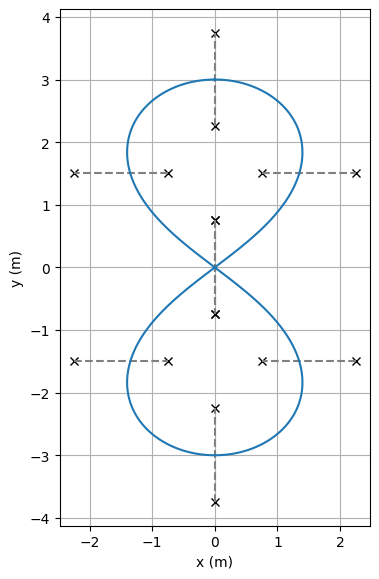

In [2]:
# DEFINE RACE TRACK
r = 1.5
gate_pos = np.array([
    [ r,  -r, -1.5],
    [ 0,   0, -1.5],
    [-r,   r, -1.5],
    [ 0, 2*r, -1.5],
    [ r,   r, -1.5],
    [ 0,   0, -1.5],
    [-r,  -r, -1.5],
    [ 0,-2*r, -1.5]
])
gate_yaw = np.array([1,2,1,0,-1,-2,-1,0])*np.pi/2
start_pos = gate_pos[0] + np.array([0,-1.,0])

fig1 = plt.figure(figsize=(4, 8))
ax1 = fig1.add_subplot(111)

for gate, yaw in zip(gate_pos, gate_yaw):
    gate_line = np.array([[-0.75, 0.0], [0.75, 0.0]])
    gate_line = (np.array([[np.cos(yaw+np.pi/2), -np.sin(yaw+np.pi/2)],[np.sin(yaw+np.pi/2),  np.cos(yaw+np.pi/2)]]) @ gate_line.T).T
    ax1.plot(gate[0]+gate_line[:, 0], gate[1]+gate_line[:, 1], 'kx')
    ax1.plot(gate[0]+gate_line[:, 0], gate[1]+gate_line[:, 1], linestyle='--', color='grey')

# Parameter for the lemniscate
a = np.sqrt(2) * r
b = 2.8

# Generate theta values for parametric equations
theta = np.linspace(0, 2 * np.pi, 1000)

# Parametric equations for the lemniscate
x = (a * np.sqrt(2) * np.cos(theta)) / (1 + np.sin(theta)**2)
y = (b * np.sqrt(2) * np.cos(theta) * np.sin(theta)) / (1 + np.sin(theta)**2)

ax1.plot(y, x)

ax1.grid()
    
ax1.set_xlabel('x (m)')
ax1.set_ylabel('y (m)')
ax1.set_aspect('equal', adjustable='box')

In [3]:
test_env = Quadcopter3DGates(
    num_envs=1,
    gates_pos=gate_pos,
    gate_yaw=gate_yaw,
    start_pos=start_pos,
    initialize_at_random_gates=False,
    randomization=randomization_fixed_params_standard,
    gates_ahead=1,
    num_state_history=0,
    num_action_history=0,
    history_step_size=1,
    param_input=False,
    param_input_noise=0.0
)

/home/elijah/miniconda3/envs/droneracing/lib/python3.10/site-packages/gymnasium/spaces/box.py:235: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
/home/elijah/miniconda3/envs/droneracing/lib/python3.10/site-packages/gymnasium/spaces/box.py:305: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(
/home/elijah/miniconda3/envs/droneracing/lib/python3.10/site-packages/stable_baselines3/common/vec_env/base_vec_env.py:77: UserWarning: The `render_mode` attribute is not defined in your environment. It will be set to None.
  warnings.warn("The `render_mode` attribute is not defined in your environment. It will be set to None.")


In [4]:
# MODEL DEFINITION
policy_kwargs = dict(activation_fn=torch.nn.ReLU, net_arch=[dict(pi=[64, 64, 64], vf=[64, 64, 64])], log_std_init = 0)
std_model = PPO(
    "MlpPolicy",
    test_env,
    policy_kwargs=policy_kwargs,
    verbose=0,
    tensorboard_log=None,   
    n_steps=1000,
    batch_size=5000,
    n_epochs=10,
    gamma=0.999
)

std_model = PPO.load('./models/real30/r150/standard_drone_3/100000000')
# std_model = PPO.load('./models/real30/r100/standard_drone_1/100000000')

/home/elijah/miniconda3/envs/droneracing/lib/python3.10/site-packages/stable_baselines3/ppo/ppo.py:155: UserWarning: You have specified a mini-batch size of 5000, but because the `RolloutBuffer` is of size `n_steps * n_envs = 1000`, after every 0 untruncated mini-batches, there will be a truncated mini-batch of size 1000
We recommend using a `batch_size` that is a factor of `n_steps * n_envs`.
Info: (n_steps=1000 and n_envs=1)
  warnings.warn(
/home/elijah/miniconda3/envs/droneracing/lib/python3.10/site-packages/stable_baselines3/common/policies.py:486: UserWarning: As shared layers in the mlp_extractor are removed since SB3 v1.8.0, you should now pass directly a dictionary and not a list (net_arch=dict(pi=..., vf=...) instead of net_arch=[dict(pi=..., vf=...)])
  warnings.warn(
/home/elijah/miniconda3/envs/droneracing/lib/python3.10/site-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run 

In [5]:
# TESTING
test_env.reset()

std_position_x = []
std_position_y = []
std_position_z = []
std_speed = []

std_p = []
std_q = []
std_r = []

std_phi = []
std_theta = []
std_psi = []

# do 1000 steps and print state and action
for i in range(1000):
    # print('step', i)
    num = test_env.num_state_history+1
    state_len = int(len(test_env.states[0])/num)

    actions, _ = std_model.predict(test_env.states, deterministic=True)
    states, rewards, dones, infos = test_env.step(actions)

    if (i+1) % 500 == 0: 
        print('step', i+1)
        print('rewards=', rewards)
        print('Num gates passed=', infos)
        print('')
    std_position_x.append(test_env.world_states[0,0])
    std_position_y.append(test_env.world_states[0,1])
    std_position_z.append(test_env.world_states[0,2])
    std_p.append(test_env.world_states[0,9]/ np.pi * 180)
    std_q.append(test_env.world_states[0,10]/ np.pi * 180)
    std_r.append(test_env.world_states[0,11]/ np.pi * 180)
    std_phi.append(test_env.world_states[0,6]/ np.pi * 180)
    std_theta.append(test_env.world_states[0,7]/ np.pi * 180)
    std_psi.append(test_env.world_states[0,8]/ np.pi * 180)
    std_speed.append(np.linalg.norm(test_env.world_states[0,3:6]))

# print(f"Max speed: {max(speed)}")
# print(f"Avg speed: {np.mean(speed)}")
# print(f"Min stable speed: {min(speed[500:])}")

np.save("sim_std_r100_x.npy", std_position_x)
np.save("sim_std_r100_y.npy", std_position_y)
np.save("sim_std_r100_z.npy", std_position_z)
np.save("sim_std_r100_speed.npy", std_speed)

step 500
rewards= [0.04696128]
Num gates passed= [{'ground_collision': np.False_, 'out_of_bounds': np.False_, 'gate_collision': np.False_, 'gate_passed': np.False_, 'num_gates_passed': array([17])}]

step 1000
rewards= [0.06767421]
Num gates passed= [{'ground_collision': np.False_, 'out_of_bounds': np.False_, 'gate_collision': np.False_, 'gate_passed': np.False_, 'num_gates_passed': array([35])}]



Text(0, 0.5, 'speed (m/s)')

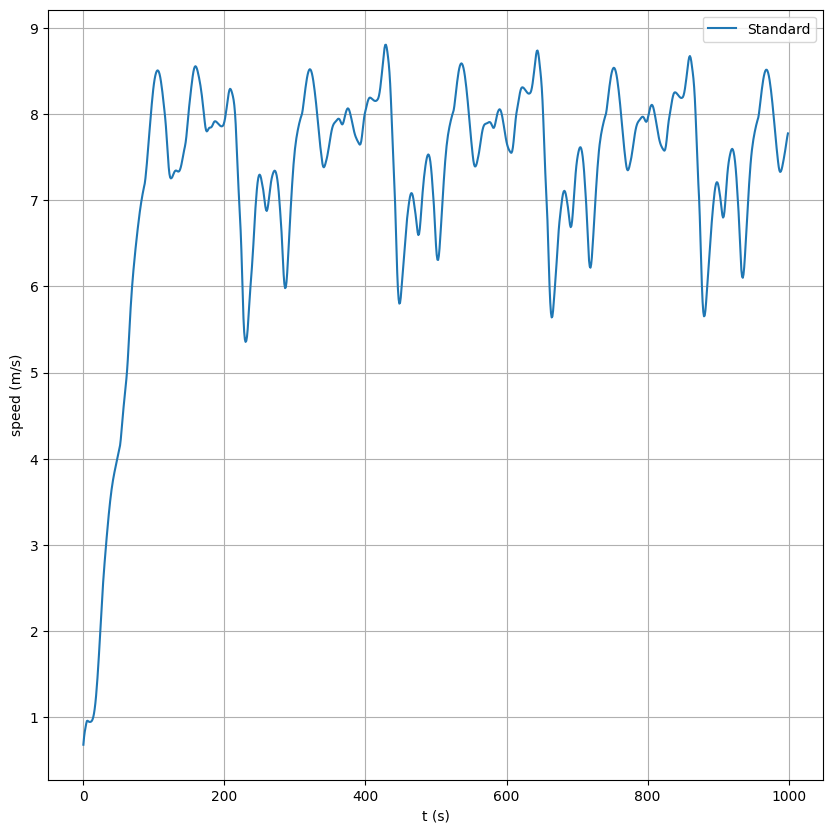

In [6]:
fig3 = plt.figure(figsize=(10,10))
ax31 = fig3.add_subplot(111)
# ax1.scatter(std_position_x, std_position_y, c=std_speed, cmap='viridis')
ax31.plot(range(1000), std_speed, label='Standard')
# ax31.plot(range(1000), lambda_speed, label='Lambda')
# ax31.plot(range(1000), alpha_speed, label='Alpha')

ax31.legend()
ax31.grid()
ax31.set_xlabel("t (s)")
ax31.set_ylabel("speed (m/s)")

Text(0, 0.5, 'angular velocity (rad/s)')

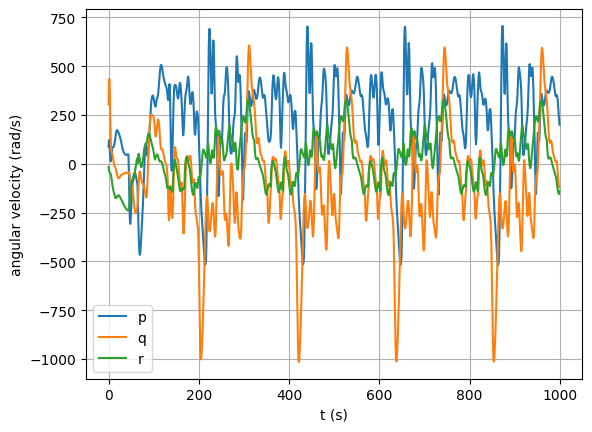

In [15]:
plt.plot(range(1000), std_p, label='p')
plt.plot(range(1000), std_q, label='q')
plt.plot(range(1000), std_r, label='r')

plt.legend()
plt.grid()
plt.xlabel("t (s)")
plt.ylabel("angular velocity (rad/s)")

Text(0, 0.5, 'orientation(rad)')

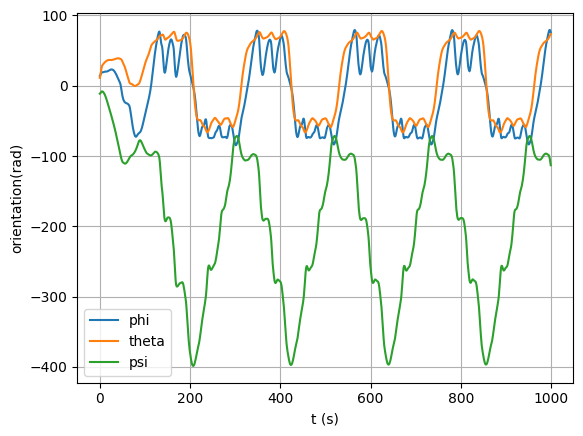

In [16]:
plt.plot(range(1000), std_phi, label='phi')
plt.plot(range(1000), std_theta, label='theta')
plt.plot(range(1000), std_psi, label='psi')

plt.legend()
plt.grid()
plt.xlabel("t (s)")
plt.ylabel("orientation(rad)")

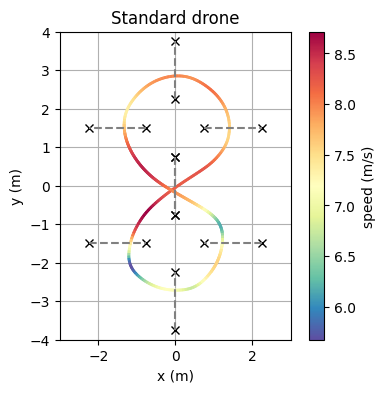

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize

idx0 = 500

# Create segments for the line
std_points = np.array([std_position_x[idx0:], std_position_y[idx0:]]).T.reshape(-1, 1, 2)
std_segments = np.concatenate([std_points[:-1], std_points[1:]], axis=1)

# Create a LineCollection
norm = Normalize(min(std_speed[idx0:]), max(std_speed[idx0:]))  # Normalize color array
std_lc = LineCollection(std_segments, cmap='Spectral_r', norm=norm)
std_lc.set_array(std_speed[idx0:])
std_lc.set_linewidth(2)  # Set line width

# Plot
fig4 = plt.figure(figsize=(16, 4)) 

ax41 = fig4.add_subplot(131)
std_line = ax41.add_collection(std_lc)
ax41.set_xlim(-3, 3)
ax41.set_ylim(-4, 4)

for gate, yaw in zip(gate_pos, gate_yaw):
    gate_line = np.array([[-0.75, 0.0], [0.75, 0.0]])
    gate_line = (np.array([[np.cos(yaw+np.pi/2), -np.sin(yaw+np.pi/2)],[np.sin(yaw+np.pi/2),  np.cos(yaw+np.pi/2)]]) @ gate_line.T).T
    ax41.plot(gate[0]+gate_line[:, 0], gate[1]+gate_line[:, 1], 'kx')
    ax41.plot(gate[0]+gate_line[:, 0], gate[1]+gate_line[:, 1], linestyle='--', color='grey')

# Add a colorbar
# cb = plt.colorbar(std_line, ax=ax41)
# cb.set_label('speed (m/s)')

ax41.grid()
ax41.set_xlabel('x (m)')
ax41.set_ylabel('y (m)')
ax41.set_aspect('equal', adjustable='box')
ax41.set_title('Standard drone')


# Add a colorbar
# cb = plt.colorbar(evo_line, ax=ax42)
cb = fig4.colorbar(std_line, orientation='vertical')
cb.set_label('speed (m/s)')





In [10]:
from real_quad_env import *
from randomization import *
from quadcopter_animation import animation

#  ANIMATION FUNCTION
def animate_policy(model, env, **kwargs):
    env.reset()
    def run():
        actions, _ = model.predict(env.states)  
        states, rewards, dones, infos = env.step(actions)        
        return env.render()
    animation.view(run, gate_pos=env.gate_pos, gate_yaw=env.gate_yaw, **kwargs)

test_env = Quadcopter3DGates(num_envs=1, gates_pos=gate_pos, gate_yaw=gate_yaw, start_pos=start_pos, gates_ahead=1, randomization=randomization_standard_30_percent)

# animate_policy(std_model, test_env)